In [1]:
import pandas as pd


In [2]:
df = pd.read_csv(r"C:\Users\Omzakolo\Downloads\employee_attrition.csv")
df

,EmployeeID,Age,Gender,Department,MonthlyIncome,YearsAtCompany,JobSatisfaction,OverTime,TrainingHours,Attrition
0,1,29,Male,Finance,94196,7,2,Yes,91,Yes
1,2,59,Female,HR,37811,2,2,Yes,69,Yes
2,3,57,Male,Operations,139974,7,4,No,5,Yes
3,4,49,Female,Finance,70758,6,3,Yes,16,No
4,5,28,Female,Finance,188263,8,1,No,73,Yes
...,...,...,...,...,...,...,...,...,...,...
495,496,28,Male,Operations,131944,7,5,No,93,Yes
496,497,46,Female,Sales,236598,21,3,Yes,6,No
497,498,34,Female,IT,196143,22,3,Yes,97,Yes
498,499,40,Female,IT,208954,2,2,Yes,99,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   EmployeeID       500 non-null    int64 
 1   Age              500 non-null    int64 
 2   Gender           500 non-null    object
 3   Department       500 non-null    object
 4   MonthlyIncome    500 non-null    int64 
 5   YearsAtCompany   500 non-null    int64 
 6   JobSatisfaction  500 non-null    int64 
 7   OverTime         500 non-null    object
 8   TrainingHours    500 non-null    int64 
 9   Attrition        500 non-null    object
dtypes: int64(6), object(4)
memory usage: 39.2+ KB


In [5]:
df.describe()

,EmployeeID,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction,TrainingHours
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,40.402000,143611.388000,12.684000,2.960000,51.648000
std,144.481833,11.167534,61455.987533,7.378145,1.410809,28.306866
min,1.000000,22.000000,31137.000000,0.000000,1.000000,5.000000
25%,125.750000,30.000000,91841.000000,6.000000,2.000000,27.000000
50%,250.500000,40.000000,144223.500000,13.000000,3.000000,51.000000
75%,375.250000,50.000000,198578.750000,19.000000,4.000000,77.000000
max,500.000000,60.000000,249408.000000,25.000000,5.000000,100.000000


In [6]:
df.isnull().sum()

EmployeeID         0
Age                0
Gender             0
Department         0
MonthlyIncome      0
YearsAtCompany     0
JobSatisfaction    0
OverTime           0
TrainingHours      0
Attrition          0
dtype: int64

In [7]:
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'Department', 'MonthlyIncome',
       'YearsAtCompany', 'JobSatisfaction', 'OverTime', 'TrainingHours',
       'Attrition'],
      dtype='object')

In [9]:
#Encoded categories
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [10]:
#define features
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [11]:
#split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [13]:
#label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Department"] = le.fit_transform(df["Department"])
df["OverTime"] = le.fit_transform(df["OverTime"])
df["Attrition"] = le.fit_transform(df["Attrition"])

In [14]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [15]:
#split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
#train model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [17]:
#check accuracy
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.63


In [18]:
#
print(X.dtypes)

EmployeeID         int64
Age                int64
Gender             int64
Department         int64
MonthlyIncome      int64
YearsAtCompany     int64
JobSatisfaction    int64
OverTime           int64
TrainingHours      int64
dtype: object


In [5]:
import matplotlib.pyplot as plt
import numpy as np

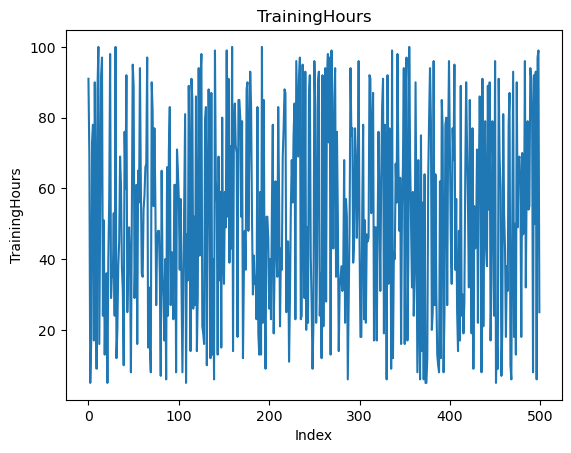

In [6]:
plt.plot(df["TrainingHours"])

plt.title("TrainingHours")
plt.xlabel("Index")
plt.ylabel("TrainingHours")

plt.show()


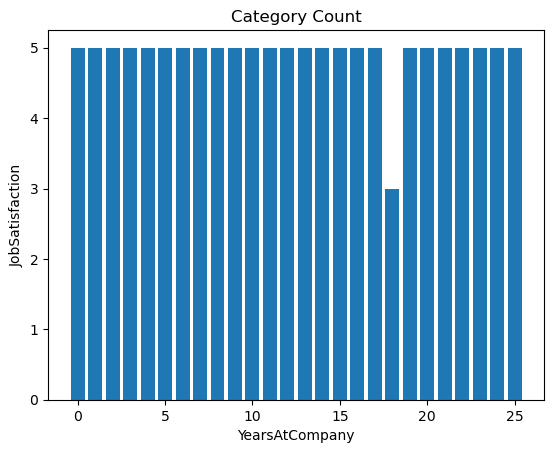

In [7]:
plt.bar(df["YearsAtCompany"], df["JobSatisfaction"])

plt.title("Category Count")
plt.xlabel("YearsAtCompany")
plt.ylabel("JobSatisfaction")

plt.show()


In [3]:
import os

print(os.getcwd())

C:\Users\Omzakolo


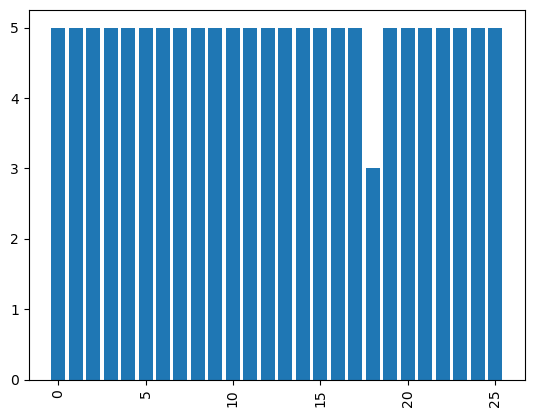

In [9]:
plt.bar(df["YearsAtCompany"], df["JobSatisfaction"])
plt.xticks(rotation=90)
plt.savefig(r"C:\Users\Omzakolo\OneDrive\Desktop\employee_attrition\bar")
plt.show()

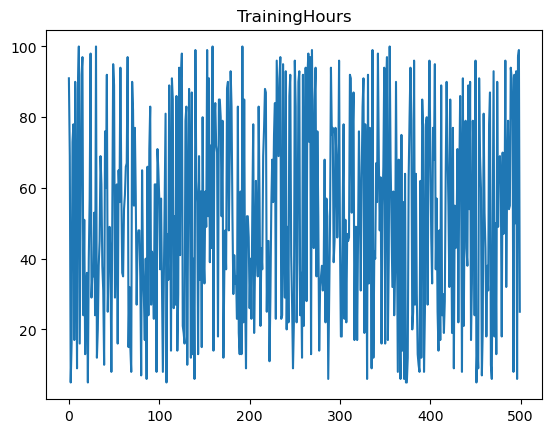

In [11]:
plt.plot(df["TrainingHours"])
plt.title("TrainingHours")
plt.savefig(r"C:\Users\Omzakolo\OneDrive\Desktop\employee_attrition\line")
plt.show()